Libraries imported successfully!

--- Dataset Sample ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms

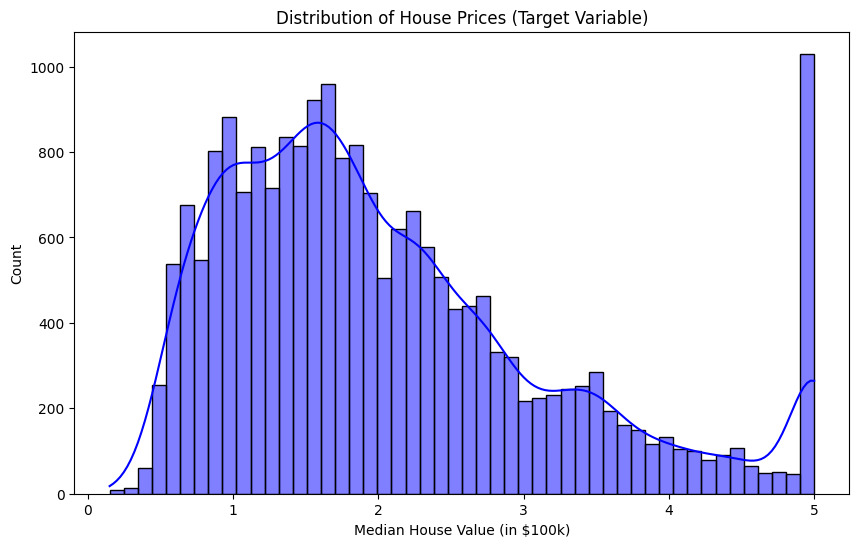

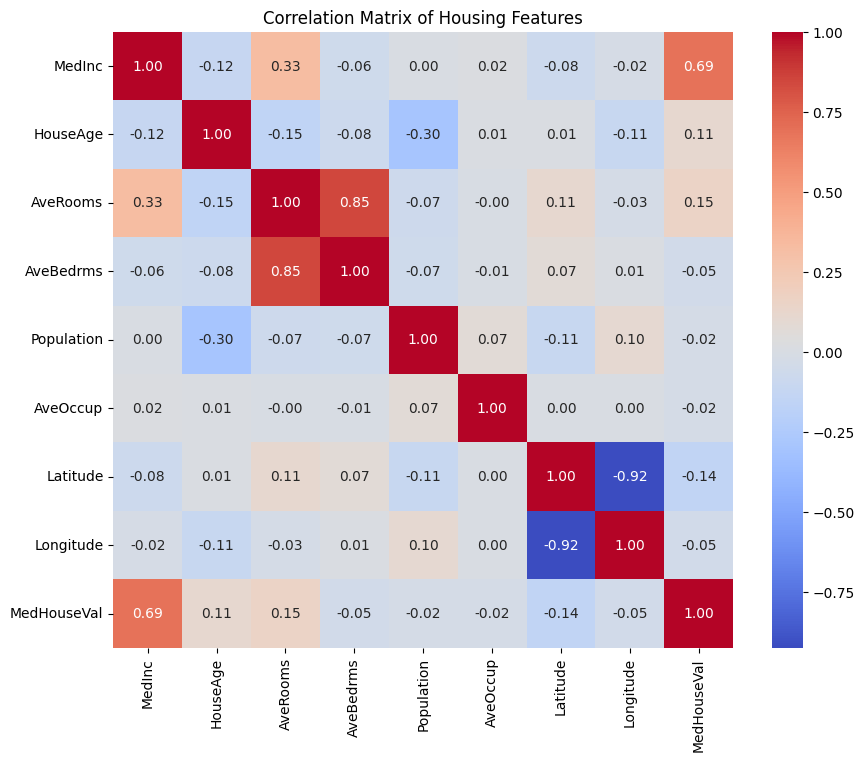


Data preprocessing and scaling completed.

Training Random Forest Regressor Model... (This may take a moment)
Model training completed!

--- Model Performance Metrics ---
Mean Absolute Error (MAE): 0.3274
Root Mean Squared Error (RMSE): 0.5051
R-squared (R2 Score): 0.8053 (80.53% variance explained)


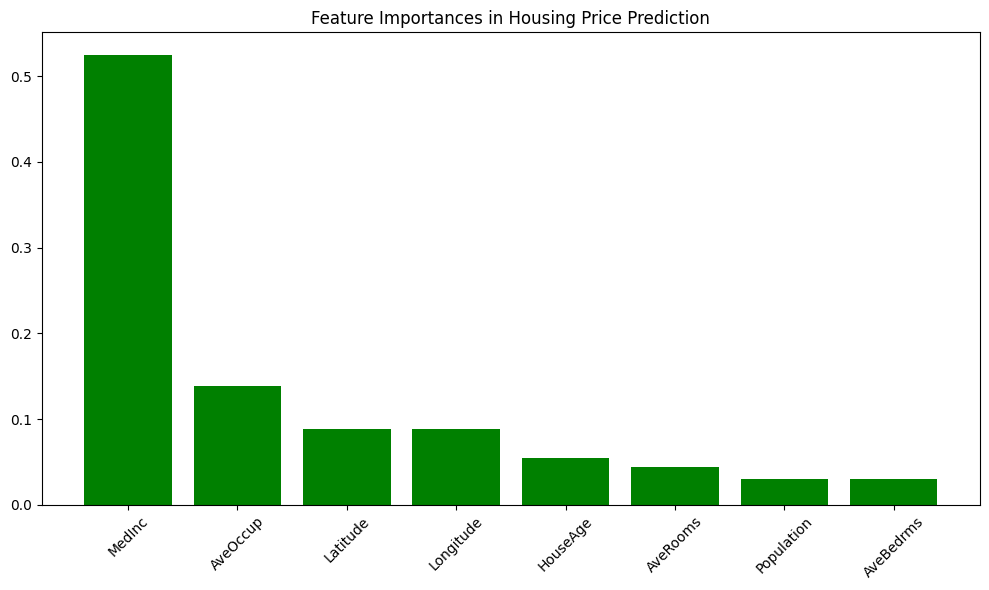

In [1]:
# ==============================================================================
# IBM SkillsBuild Data Analytics with AI Internship
# Project: Housing Price Analytics & AI Prediction
# ==============================================================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Libraries imported successfully!")

# 2. LOAD DATASET
california = fetch_california_housing(as_frame=True)
df = california.frame

# Display first few rows
print("\n--- Dataset Sample ---")
print(df.head())

# 3. DATA CLEANING & EXPLORATION
print("\n--- Dataset Information ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

# 4. EXPLORATORY DATA ANALYSIS (EDA)
plt.figure(figsize=(10, 6))
sns.histplot(df['MedHouseVal'], kde=True, bins=50, color='blue')
plt.title('Distribution of House Prices (Target Variable)')
plt.xlabel('Median House Value (in $100k)')
plt.ylabel('Count')
plt.show()

# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Housing Features')
plt.show()

# 5. DATA PREPROCESSING
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing and scaling completed.")

# 6. AI MODEL TRAINING (Random Forest Regressor)
print("\nTraining Random Forest Regressor Model... (This may take a moment)")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)
print("Model training completed!")

# 7. MODEL EVALUATION
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f} ({r2*100:.2f}% variance explained)")

# 8. FEATURE IMPORTANCE VISUALIZATION
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importances in Housing Price Prediction")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='green')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()
